# Dataset diagnostics

Three quick checks to understand how much signal is in the dataset before committing to a model design:

1. **Frame identity rate**: what fraction of consecutive frames are pixel-identical?
2. **Pixel-change distribution**: how many cells flip per step?
3. **θ quantization ceiling**: the smallest rotation that changes a pixel, per resolution. The hard observability floor for heading - no model can beat this.

> To generate `data/diagnostics.py` for importing, run from `PHYSWM/`:
> ```
> jupyter nbconvert --to python data/diagnostics.ipynb
> ```

## Path setup

Same root-finding pattern as `collect.ipynb` and `coverage.ipynb`.

In [30]:
import sys
from pathlib import Path

# Walk up from the current dir to find the project root (the folder with constants.py).
ROOT = next(p for p in (Path.cwd(), *Path.cwd().parents) if (p / "constants.py").exists())
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

## Imports

In [31]:
import h5py
import numpy as np
import numpy.typing as npt
import matplotlib.pyplot as plt
from matplotlib.axes import Axes
from typing import Optional, Union
from sim.render import render_frame
from sim.visualize import show_frame_strip

## Load dataset

`load_h5` reads all arrays from an HDF5 file into a dict. Reusable across all notebooks. Set `load_frames=False` if you only need states/actions and want to avoid loading the (potentially large) frame array.

In [32]:
def load_h5(h5_path: Union[str, Path], load_frames: bool = True) -> dict:
    """Load arrays from an HDF5 dataset file into memory.

    Parameters
    ----------
    h5_path : str or Path
        Input .h5 file from collect_dataset.
    load_frames : bool
        Load the full frames array. Set False to save memory when you only
        need states/actions/episode metadata.

    Returns
    -------
    dict
        Keys: attrs, states, actions, episode_starts, episode_lengths,
        termination, and frames (if load_frames is True).
    """
    h5_path = Path(h5_path)
    if not h5_path.exists():
        raise FileNotFoundError(f"no such file: {h5_path}")
    with h5py.File(h5_path, "r") as f:
        data = {
            "attrs":            dict(f.attrs),
            "states":           f["states"][:],
            "actions":          f["actions"][:],
            "episode_starts":   f["episode_starts"][:],
            "episode_lengths":  f["episode_lengths"][:],
            "termination":      f["termination"][:],
        }
        if load_frames:
            data["frames"] = f["frames"][:]
    return data

In [33]:
data = load_h5(ROOT / "data" / "datasets" / "run02.h5")
frames          = data["frames"]
states          = data["states"]
actions         = data["actions"]
episode_starts  = data["episode_starts"]
episode_lengths = data["episode_lengths"]
attrs           = data["attrs"]

## Frame identity rate

What fraction of consecutive frame pairs within episodes are pixel-identical? Expected to be low - translation alone (`v_mean·dt ≈ 0.018` world units ≈ 0.7 cells at 40×40) keeps most frames distinct even when rotation is sub-pixel.

In [34]:
def frame_identity_rate(
    frames: np.ndarray, episode_starts: np.ndarray, episode_lengths: np.ndarray
) -> float:
    """Fraction of consecutive frame pairs within episodes that are pixel-identical.

    Parameters
    ----------
    frames : np.ndarray, shape (T, H, W)
        Binary occupancy frames.
    episode_starts : np.ndarray, shape (E,)
    episode_lengths : np.ndarray, shape (E,)

    Returns
    -------
    float
        Fraction of consecutive pairs that are identical.
    """
    identical = 0
    total = 0
    for s, L in zip(episode_starts, episode_lengths):
        ep = frames[s : s + L]
        identical += int(np.all(ep[:-1] == ep[1:], axis=(1, 2)).sum())
        total += L - 1
    return identical / total if total > 0 else 0.0

In [35]:
rate = frame_identity_rate(frames, episode_starts, episode_lengths)
print(f"identical: {rate:.2%}")

identical: 2.08%


## Per-step pixel-change distribution

How many cells flip between consecutive frames within episodes. Zero means the frame is truly identical; even a handful of boundary cells flipping gives the encoder something to work with.

In [36]:
def pixel_change_distribution(
    frames: np.ndarray,
    episode_starts: np.ndarray,
    episode_lengths: np.ndarray,
    ax: Optional[Axes] = None,
) -> np.ndarray:
    """Cells flipped between consecutive frames within episodes.

    Parameters
    ----------
    frames : np.ndarray, shape (T, H, W)
        Binary occupancy frames.
    episode_starts : np.ndarray, shape (E,)
    episode_lengths : np.ndarray, shape (E,)
    ax : matplotlib Axes, optional
        Where to draw. If None, a new figure is created.

    Returns
    -------
    np.ndarray, shape (total_transitions,)
        Number of cells that changed per step.
    """
    chunks = []
    for s, L in zip(episode_starts, episode_lengths):
        ep = frames[s : s + L]
        chunks.append((ep[:-1] != ep[1:]).sum(axis=(1, 2)))
    diffs = np.concatenate(chunks) if chunks else np.array([], dtype=int)

    if ax is None:
        _, ax = plt.subplots()
    max_diff = int(diffs.max()) if len(diffs) > 0 else 10
    ax.hist(diffs, bins=np.arange(-0.5, max_diff + 1.5, 1))
    ax.set_xlabel("cells flipped")
    ax.set_ylabel("frequency")
    ax.set_title("per-step pixel-change distribution")
    return diffs

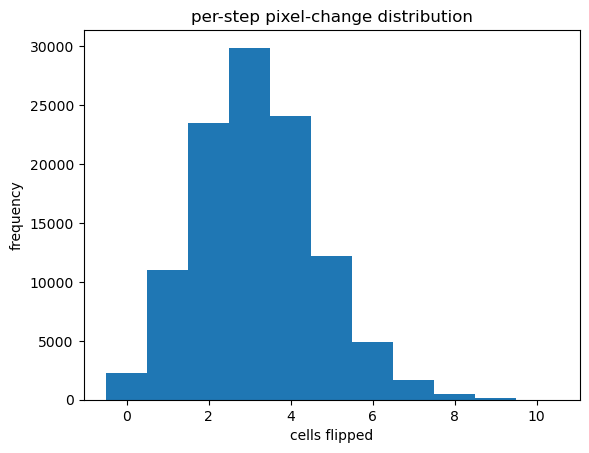

median: 3 cells/step  |  zero-change steps: 2.1%


In [37]:
_, ax = plt.subplots()
diffs = pixel_change_distribution(frames, episode_starts, episode_lengths, ax=ax)
plt.show()
print(f"median: {int(np.median(diffs))} cells/step  |  "
      f"zero-change steps: {(diffs == 0).mean():.1%}")

## θ quantization ceiling

Fix the robot at the arena center, sweep θ over [-π, π) in 1° steps, and find where consecutive renders first differ. The gaps between those angles are the quantization intervals - the hard observability floor for heading. No model can recover θ finer than this.

Also shows a frame strip at sample headings so you can see the coarseness directly.

In [ ]:
def theta_quantization_ceiling(
    resolutions: list = [40, 64, 84], center: tuple = (0.5, 0.5)
) -> dict:
    """Smallest rotation (degrees) that visibly changes a pixel, per resolution.

    Fix the robot at `center`, sweep θ in 1° steps, and find where consecutive
    renders differ. Gaps between flip angles = the quantization intervals.

    Parameters
    ----------
    resolutions : list of int
        Grid sizes to test.
    center : (x, y) tuple
        World position to fix the robot at.

    Returns
    -------
    dict mapping grid_size (int) -> dict with keys:
        mean_deg, min_deg, max_deg, flip_angles (np.ndarray, radians).
    """
    thetas = np.linspace(-np.pi, np.pi, 360, endpoint=False)
    results = {}
    for grid_size in resolutions:
        flipped_at = []
        prev = render_frame([*center, thetas[0]], grid_size=grid_size)
        for theta in thetas[1:]:
            curr = render_frame([*center, theta], grid_size=grid_size)
            if not np.array_equal(prev, curr):
                flipped_at.append(theta)
                prev = curr
        gaps = np.degrees(np.diff(flipped_at))
        results[grid_size] = {
            "mean_deg":     float(gaps.mean()),
            "min_deg":      float(gaps.min()),
            "max_deg":      float(gaps.max()),
            "flip_angles":  np.array(flipped_at),
        }
        print(f"{grid_size:2d}x{grid_size:2d}:  min={gaps.min():.1f}°  "
              f"mean={gaps.mean():.1f}°  max={gaps.max():.1f}°")
    return results

40x40:  min=1.0°  mean=5.0°  max=15.0°
64x64:  min=1.0°  mean=2.1°  max=6.0°
84x84:  min=1.0°  mean=1.5°  max=4.0°


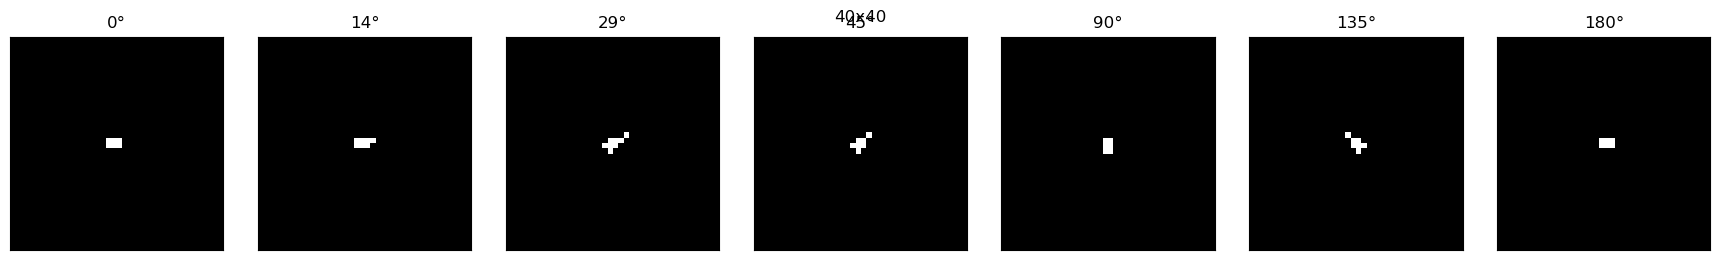

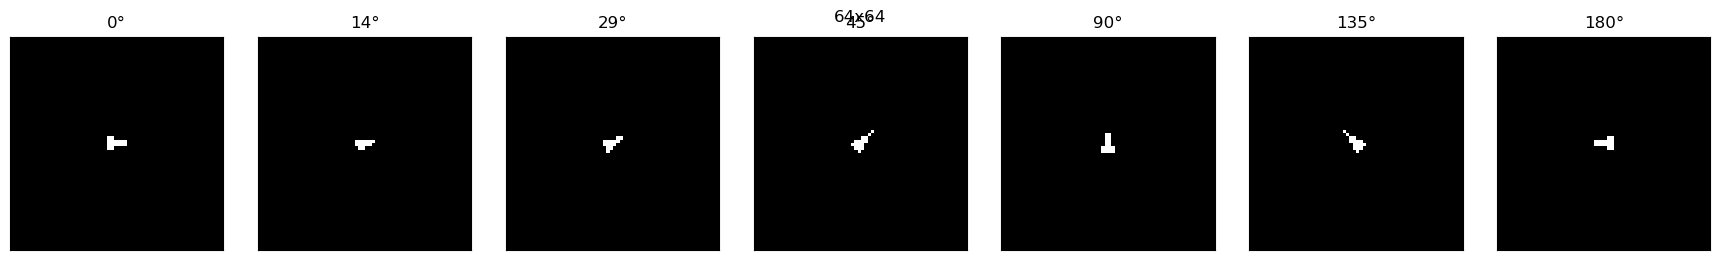

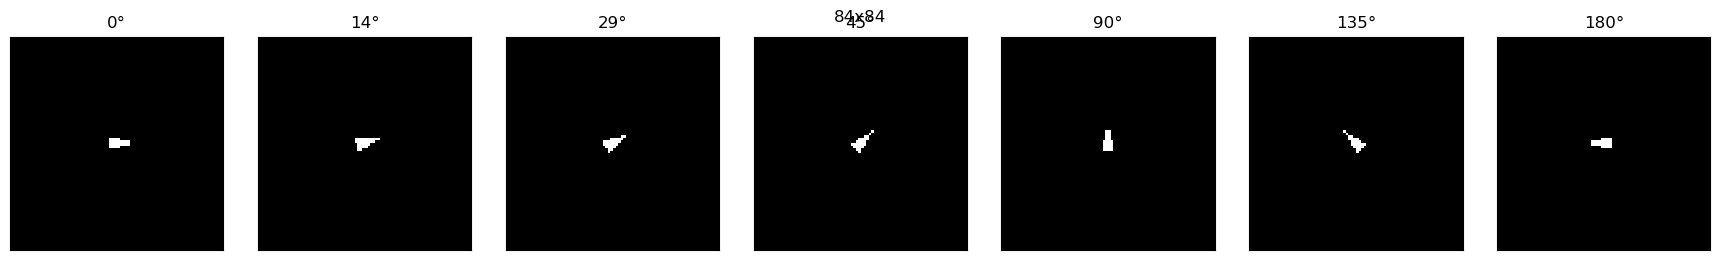

In [ ]:
results = theta_quantization_ceiling()

# Frame strip at sample headings - makes the quantization coarseness visible.
sample_thetas = np.radians([0, 15, 30, 45, 90, 135, 180])
for grid_size in [40, 64, 84]:
    strip = [render_frame([0.5, 0.5, t], grid_size=grid_size) for t in sample_thetas]
    fig = show_frame_strip(strip, titles=[f"{int(np.degrees(t))}°" for t in sample_thetas])
    fig.suptitle(f"{grid_size}x{grid_size}", y=1.02)
    plt.show()